In [1]:
#!/bin/bash
!curl -L -o breast-cancer-wisconsin-data.zip\
  https://www.kaggle.com/api/v1/datasets/download/uciml/breast-cancer-wisconsin-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 49796  100 49796    0     0   171k      0 --:--:-- --:--:-- --:--:--  171k


In [2]:
!unzip /content/breast-cancer-wisconsin-data.zip

Archive:  /content/breast-cancer-wisconsin-data.zip
  inflating: data.csv                


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/data.csv')

In [5]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
drop_cols = ['id', 'Unnamed: 32']

df = df.drop(columns=drop_cols, errors='ignore')

In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [11]:
print(y.value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

In [14]:
X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [16]:
X_scaled_df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [17]:
from sklearn.decomposition import PCA

In [18]:
pca = PCA()

In [19]:
pca.fit(X_scaled)

PCA()

In [21]:
explained_variance_ratio = pca.explained_variance_ratio_

for i, proportion in enumerate(explained_variance_ratio[:5], 1):
    print(f"Komponent {i}: {proportion*100:.2f}%")

cumulative_variance = np.cumsum(explained_variance_ratio)

print()
print(cumulative_variance[0]*100)
print(cumulative_variance[1]*100)
print(cumulative_variance[2]*100)
print(cumulative_variance[4]*100)
print(cumulative_variance[9]*100)

Komponent 1: 44.27%
Komponent 2: 18.97%
Komponent 3: 9.39%
Komponent 4: 6.60%
Komponent 5: 5.50%

44.272025607526366
63.243207651559445
72.63637090899083
84.73427431680724
95.1568814336667


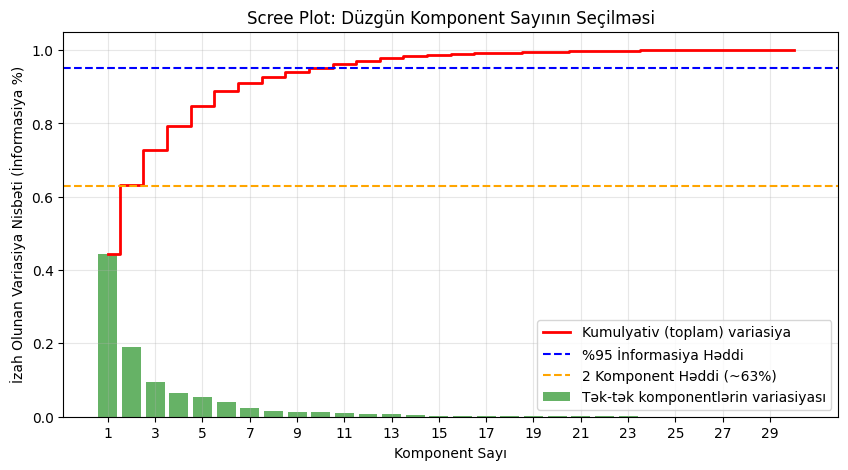

In [22]:
plt.figure(figsize=(10, 5))

plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6,
        label='Tək-tək komponentlərin variasiyası', color='g')

plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
         label='Kumulyativ (toplam) variasiya', color='red', linewidth=2)

plt.xlabel('Komponent Sayı')
plt.ylabel('İzah Olunan Variasiya Nisbəti (İnformasiya %)')
plt.title('Scree Plot: Düzgün Komponent Sayının Seçilməsi')
plt.axhline(y=0.95, color='blue', linestyle='--', label='%95 İnformasiya Həddi')
plt.axhline(y=0.63, color='orange', linestyle='--', label='2 Komponent Həddi (~63%)')
plt.xticks(range(1, 31, 2))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

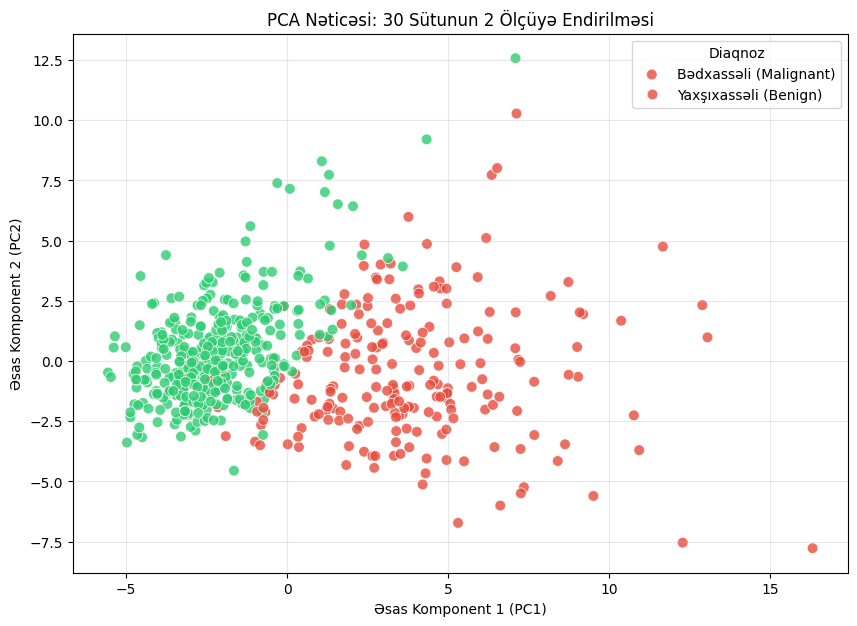

In [23]:
pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Məlhəm_Komponent_1', 'Məlhəm_Komponent_2'])

pca_df['Diagnosis'] = y.values

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Məlhəm_Komponent_1', y='Məlhəm_Komponent_2', hue='Diagnosis',
                data=pca_df, palette={'M': '#e74c3c', 'B': '#2ecc71'}, alpha=0.8, s=60)

plt.xlabel('Əsas Komponent 1 (PC1)')
plt.ylabel('Əsas Komponent 2 (PC2)')
plt.title('PCA Nəticəsi: 30 Sütunun 2 Ölçüyə Endirilməsi')
plt.legend(title='Diaqnoz', labels=['Bədxassəli (Malignant)', 'Yaxşıxassəli (Benign)'])
plt.grid(True, alpha=0.3)
plt.show()